먼저 API Key 동작 테스트부터 시작합니다.
- Upstage API Key로 테스트합니다.

# 1. API Key / LangGraph 세팅 점검하기

In [44]:
from dotenv import load_dotenv
load_dotenv() # .env파일에서 환경설정 가져오기

True

In [45]:
import os
from openai import OpenAI

# Upstage API
client = OpenAI(api_key=os.getenv("UPSTAGE_API_KEY"), base_url="https://api.upstage.ai/v1")

model = "solar-pro3"
prompt="KFC 버거 추천좀 해줘, 두줄 요약"

response = client.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
print(response.choices[0].message.content)

Okay, the user is asking for a KFC burger recommendation, but they want it in two lines. Let me think about how to approach this.

First, I need to recall popular KFC burgers. The Zinger Burger is a classic, known for its spicy chicken patty. There's also the Colonel's Chicken Burger, which is a bit different with a different seasoning. Maybe the Double Down, which is a sandwich with bacon and cheese, but not sure if they consider that a burger. Wait, the Double Down is more of a sandwich, but maybe the user is okay with that.

Wait, the user said "버거" which is burger, so maybe they are looking for traditional burgers. The Zinger is a good choice. Also, the Original Recipe burger uses their secret recipe. But KFC's main burgers are Zinger and maybe some limited editions.

I should check if there are any recent menu items. Since my knowledge cutoff is 2025-07, but the current date is 2026-03, maybe there are new items. But I don't have info beyond 2025, so I'll stick to the known ones.


아래 코드는 랭그래프가 정상 동작되는지 테스트입니다. 

가볍게 실행하여 잘 동작되는지 확인해주세요.

In [46]:
from typing_extensions import TypedDict, Annotated
import operator
import os

from langchain.chat_models import init_chat_model
from langchain.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain_upstage import ChatUpstage  # Upstage

# OpenAI API는 아래 주석을 풀고 쓰세요.
#model = init_chat_model("gpt-5-nano", temperature=0)

# Upstage API는 아래 주석을 풀고 쓰세요.
model = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)

# 랭그래프에서 State는 전역변수처럼 모든 Node들이 데이터를 저장할 수 있는 공간입니다.
class State(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


def BBQ(state: State):
    return {"messages": [model.invoke(state["messages"])]}


graph = StateGraph(State)
graph.add_node("BBQ", BBQ)
graph.add_edge(START, "BBQ")
graph.add_edge("BBQ", END)

agent = graph.compile()


result = agent.invoke({
    "messages": [HumanMessage(content="KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약")]
})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약
================================== Ai Message ==================================

"취향 차이: KFC는 바삭한 튀김, 맥도날드는 가벼운 맛 선호에 따라 선택"


# 2. RAG 이해하기 (이론)

### RAG는 기술입니다. RAG를 해봅시다.

RAG는 기술 이름입니다~.

LLM에 사용자 질문과, 검색된 관련 정보를 함께 LLM에 넣어주는 기술입니다.

LLM이 더 똑똑하게 대답할수 있습니다.

아래 예시 이미지를 보면, 둘중 어느것이 검색결과가 더 좋을까요?
1. "오늘날씨어때?" 프롬프트를 LLM을 넣었을 때 결과
2. "오늘날씨어때?(구글검색결과:비옴)" 프롬프트를 LLM을 넣었을 때 결과

당연히 2번이 LLM 답변 품질이 더 좋겠죠?

이렇게 LLM에 프롬프트를 넣기 전, "**관련 내용을 검색하여 프롬프트를 보강**" 하는 기술을 RAG 라고 부릅니다.

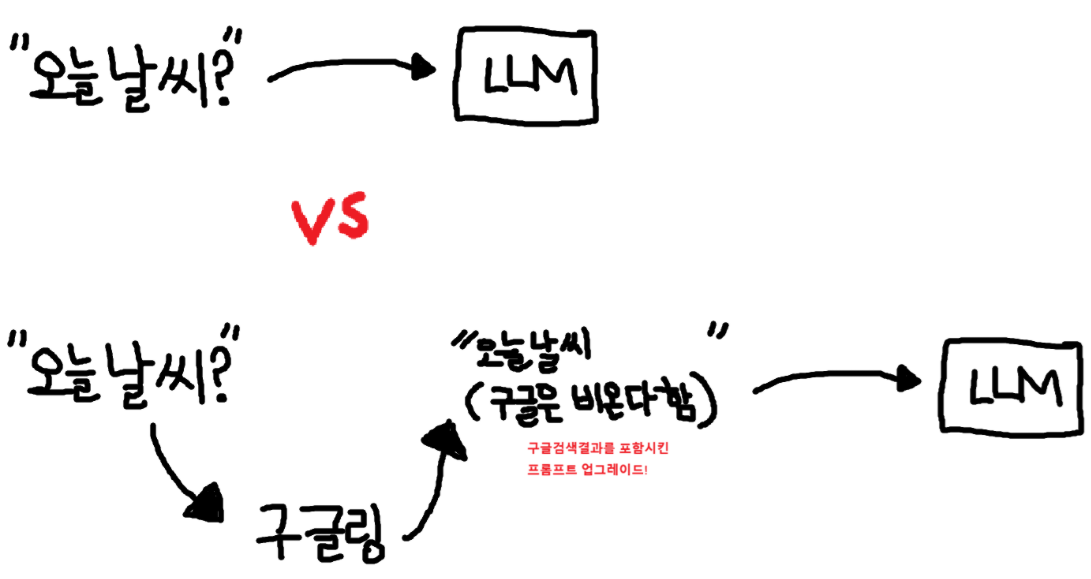


RAG는 기술이므로, "RAG 했다." 라고 부르곤 합니다.

우리 수업에서는 RAG를 할 예정입니다.

RAG는 기업에서 많이 사용됩니다.

- 질문이 들어왔을 때, 자동으로 사내문서 / 사내시스템에 유사한 내용을 검색 후 LLM에게 물어보도록 합니다.

RAG를 통해서, 제미나이, GPT 같은 거대한 모델이 모르는.. 우리 회사만의 비공개 정보를 LLM에게 알려줄수 있는 것이죠.

### RAG를 위한 준비물

먼저 사내문서들을 DB에 저장해두어야겠죠?

사내문서를 DB에 저장할때 두 가지 선택지가 있습니다.
- Text 원본 그대로 DB에 저장해두기
    - 차후 검색시, 완벽히 동일한 단어 중심으로 검색을 하게 됩니다~!
- Text들을 임베딩해서 DB에 의미벡터값으로 저장해두기
    - 차후 검색시, 완벽한 동일한 단어가 아니라 의미가 유사한 단어로 검색이 가능합니다~!
 
우리 실습은 '임베딩'을 하는 방법을 통해 '유사도 검색'이 가능하도록 하겠습니다.
 - 이러면 정확한 단어로 검색하지 않아도, 유사성이 높은 단어들로 검색이 더 잘될겁니다.

그러면 다음과 같은 준비물이 필요합니다.

1. 사내문서 Text
2. Text를 임베딩하여 의미공간의 벡터값으로 변경할 "임베딩모델"
3. 마지막으로 임베딩 값을 저장할 "DB"
4. Cosine 유사도가 높은 단어가 있는 문서를 검색해주는 "Retriever" Library

생각보다 준비물이 많아요.

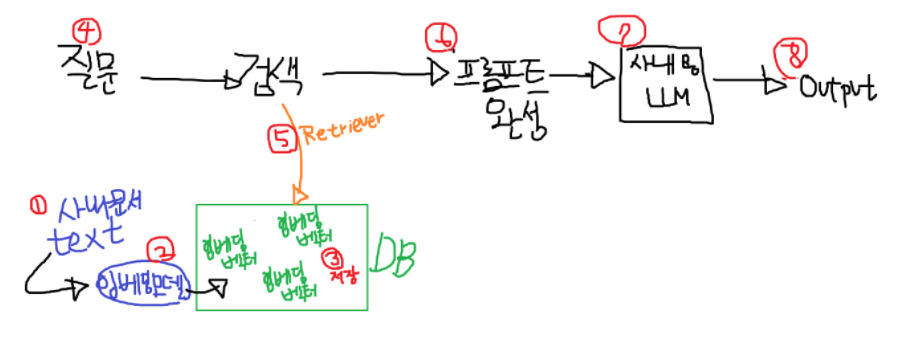

위 이미지를 이해하면, RAG 동작 원리를 파악한 것입니다!
- 준비 단계
1. 사내 문서 Text로 추출하여, "Chunk" 라는 단락 단위로 나눕니다.
2. "Chunk" 를 임베딩모델의 입력값으로 넣어, 벡터로 만들어냅니다.
3. 만들어진 벡터를 DB에 저장합니다.
- Workflow 동작
4. 질문 프롬프트를 입력 받습니다.
5. 임베딩 모델을 거쳐 벡터 값을 얻어낸 후, Retriever로 유사한 Chunk를 검색합니다.
6. 기존 질문과, 검색결과를 합쳐 프롬프트를 완성합니다.
7. 프롬프트를 LLM에 입력으로 넣습니다.
8. 더 멋진 결과가 나옵니다.

### RAG에 대한 Q&A
- Q. DB는 뭘 쓰나요?
- A. Vector 저장과 빠른 검색을 위한 Vector DB가 존재합니다. (Chroma, FAISS 등) <br/>
     그런데 그냥 MySQL을 써도 됩니다. MySQL 9.0 부터는 Vector도 지원되거든요.

<br/>

- Q. 왜 문서를 Chunk 단위로 쪼개나요?
- A. LLM이 거대한 문서 입력을 못받아들여서요.

<br/>

- Q. 문서 내용을 Chunk단위로 나눈다고 했는데, 몇 글자 정도로 나누나요?
- A. 보통 300 ~ 1000 토큰정도면 됩니다. 이정도면 LLM도 부담없고, 검색에 필요한 정보는 충분히 담길꺼예요. <br/>
   (한글 문장 수로 보면 한 20문장 정도)

<br/>

- Q. Chunk 단위로 자르면, 정보가 중간에 짤리는 것 아니예요?
- A. 네 맞습니다. 그래서 겹치는 구간(Overlap)을 두면서 Chunk로 자릅니다.

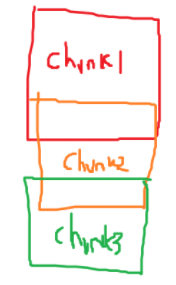

# 3. RAG 준비 단계

실습에는 다음과 같은 모델과 DB를 사용합니다.
    
- 임베딩모델은 Upstage의 임베딩 모델을 사용합니다.
- vector DB는 chromadb를 사용합니다.
- LLM모델은 Upstage 모델을 사용합니다.

다음 패키지를 사용합니다.
- langchain_community
  - 랭체인에서 자주사용되는 모듈들이 있습니다.
  - Text 파일을 불러오는데 사용되는 Loader, Vector DB와 연동해주는 모듈 등이 있습니다.
- langchain-chroma
  - 실습에 사용할 Vector DB 입니다.
  - vector값들을 저장하고, vector값을 검색해주는 검색기를 제공합니다.

In [19]:
!pip install -U langchain_community langchain-chroma

### Text 준비하기

실습을 위한 소설을 준비했습니다. 제목은 "차윤이의 레고세상" 입니다.

RAG가 잘 동작되는지 테스트를 하기 위해서는, LLM이 모르는 정보의 데이터가 필요하기 때문에 자작소설을 준비했습니다.

- 아래 코드를 수행하면, ./chayoon_lego/chayoon_lego_world.pdf 파일로 소설이 저장됩니다.  

In [29]:
!git clone https://github.com/mincoding-ai/chayoon_lego.git

fatal: destination path 'chayoon_lego' already exists and is not an empty directory.


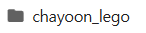

아래 코드는 PDF의 Text를 불러오고, 200자 단위로 자릅니다.

이 단위를 Chunk라고 하고, 40글자 Overlap이 되도록 세팅하였습니다.

In [28]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Load: PDF 파일 불러오기
loader = PyPDFLoader("./chayoon_lego/chayoon_lego_world.pdf")
documents = loader.load()

# 2. Split: 문서를 200자 단위로 자르기 (40자 overlap)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=40
)
chunks = splitter.split_documents(documents)

print("\n--- 200자 단위로 잘린 문서 조각(Chunk)들 ---")
for i, chunk in enumerate(chunks):
    print(f"[📜Chunk {i+1}]")
    print(chunk.page_content)
    print()


--- 200자 단위로 잘린 문서 조각(Chunk)들 ---
[📜Chunk 1]
민코딩 단편 소설 시리즈 
차윤이의  레고 세상 
 
차윤이가  다섯 살이 되던 봄이었다 . 
생일날  아빠는  작은 상자 하나를  내밀었다 . 상자에는  번쩍이는  레이싱카  레고 그림이  그
려져 있었다 . 
 
“차윤아 , 한번 만들어  볼래?” 
 
차윤이는  상자를  열자마자  눈이 커졌다 . 빨간색과  노란색이  섞인 작은 블록들 , 반짝이는

[📜Chunk 2]
바퀴, 그리고  무엇보다도  작은 레고 카레이서  피규어가  있었다 . 헬멧을  쓴 작은 사람이  
차 안에 앉아 있었다 . 
 
차윤이는  숨을 들이켰다 . 
 
“와… 진짜 멋있다 …” 
 
차윤이는  그날 저녁 내내 레고를  조립했다 . 
작은 손으로  하나씩  맞추고 , 설명서를  뒤적이며  블록을  찾았다 .

[📜Chunk 3]
마침내  레이싱카가  완성되자  차윤이는  레고 카레이서를  손에 들고 오래 바라보았다 . 
 
그 작은 사람의  손은 둥글게  C 모양으로  굽어 있었다 . 
 
차윤이는  그 손을 따라 해 보았다 . 
 
C 모양.

[📜Chunk 4]
그 순간 차윤이는  깨달았다 . 
 
“나도 레고 사람이야 .” 
 
다음 날부터  차윤이는  레고처럼  살기 시작했다 . 
 
손은 항상 C 모양이었다 . 
레고 사람처럼  물건을  잡는 손. 
 
차윤이는  손을 펴지 않았다 . 
 
걸을 때도 레고처럼  걸었다 . 
무릎을  거의 굽히지  않고, 허리를  크게 돌리지  않았다 .

[📜Chunk 5]
무릎을  거의 굽히지  않고, 허리를  크게 돌리지  않았다 . 
조금 딱딱하게 , 조금 삐걱거리게 . 
 
차윤이는  그게 멋있다고  생각했다 . 
 
거울을  보며 중얼거렸다 . 
 
“나는 레고 카레이서야 .” 
 
일주일  동안 차윤이는  계속 그렇게  다녔다 . 
 
유치원에서도 .

[📜Chunk 6]
집에서도 . 
심지어  축구교실에서도 . 
 
코치 선생님이  말했다 . 

### Chunk를 임베딩 벡터로 변환 후 Vector DB에 저장하기
vector DB는 chromaDB를 사용합니다.
 - chromaDB는 내부적으로 SQLite 기반으로 구현되어있습니다.
 - 아래 코드를 수행하면 "./chroma_store"라는 폴더가 생성 후 폴더 내부에 저장됩니다.

임베딩 모델은 Upstage의 유료 임베딩 모델을 사용합니다.

In [31]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

# OpenAI의 임베딩모델
#embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Upstage의 임베딩모델
from langchain_upstage import UpstageEmbeddings
embeddings = UpstageEmbeddings(model="embedding-query")

# 잘라낸 문서 조각(chunks)들을 임베딩하여 Vector DB에 저장합니다.
vector_store = Chroma(
    embedding_function=embeddings,
    persist_directory="./chroma_store",
)

vector_store.add_documents(chunks)
print("Chunk들을 Vector DB에 저장 완료")

Chunk들을 Vector DB에 저장 완료


### 검색기(Retriever) 생성 후, 테스트
- chromaDB는 검색기(retriever)도 제공합니다.
- Vector Store 객체가 질문과 관련된 정보를 잘 찾아주는지 테스트해볼까요?

In [36]:
retriever = vector_store.as_retriever()

question = "차윤이 손 모양은?"

# retriever.invoke(질문) 을 실행하면, 질문과 가장 관련 높은 문서 조각을 찾아줍니다.
# question을 임베딩벡터로 변환 후 검색을 시작합니다.
retrieved_docs = retriever.invoke(question)

print(f"[질문]: {question}")
print(f"\n[검색 결과]:\n{retrieved_docs[0].page_content}")

[질문]: 차윤이 손 모양은?

[검색 결과]:
마침내  레이싱카가  완성되자  차윤이는  레고 카레이서를  손에 들고 오래 바라보았다 . 
 
그 작은 사람의  손은 둥글게  C 모양으로  굽어 있었다 . 
 
차윤이는  그 손을 따라 해 보았다 . 
 
C 모양.


# 4. LangGraph로 RAG 구현하기

드디어 준비가 다 되었습니다.

LangGraph로 RAG를 쓴 AI Workflow를 구현합니다.

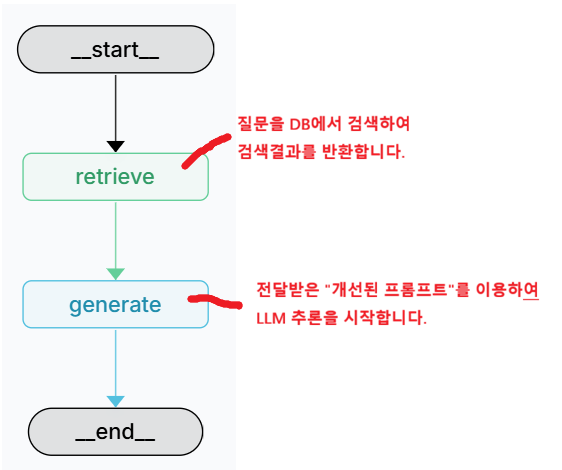

In [40]:
from typing_extensions import TypedDict, Annotated
import operator
import os

from langchain.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langchain_upstage import ChatUpstage

# ===== 기존 Vector DB 그대로 사용 =====
# (이미 위에서 만든 vector_store, retriever 재사용)

# ===== LLM =====
model = ChatUpstage(model="solar-pro", upstage_api_key=os.getenv("UPSTAGE_API_KEY"), temperature=0)

# ===== State 정의 =====
class State(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    context: str


# ===== 1. Retrieve Node =====
def retrieve(state: State):
    question = state["messages"][-1].content
    
    docs = retriever.invoke(question) # 여러 청크를 검색한다.
    
    context = "\n\n".join([doc.page_content for doc in docs]) # 여러 청크들을 하나의 String으로 합친다.
    
    return {"context": context}


# ===== 2. Generate Node (LLM) =====
def generate(state: State):
    question = state["messages"][-1].content
    context = state["context"] # retrieve의 결과

    prompt = f"""
너는 문서를 기반으로 정확하게 답하는 AI야.

[문서 내용]
{context}

[질문]
{question}

문서를 기반으로만 답변해.
"""

    response = model.invoke([
        SystemMessage(content="너는 RAG 기반 QA 시스템이다."),
        HumanMessage(content=prompt)
    ])

    return {"messages": [response]}


# ===== Graph 구성 =====
graph = StateGraph(State)

graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

agent = graph.compile()


# ===== 실행 =====
result = agent.invoke({
    "messages": [HumanMessage(content="차윤이 손 모양은?")]
})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

차윤이 손 모양은?
================================== Ai Message ==================================

차윤이의 손 모양은 **C 모양**입니다. 

문서에서 다음과 같이 명시되어 있습니다:  
- "그 작은 사람의 손은 둥글게 C 모양으로 굽어 있었다."  
- "차윤이는 그 손을 따라 해 보았다. C 모양."  
- "엄마도 손이 C 모양이었다."  
- "아빠의 손도 C 모양이었다."  
- "다음 날부터 차윤이는 레고처럼 살기 시작했다. 손은 항상 C 모양이었다."  

따라서 차윤이는 레고 사람처럼 손을 항상 C 모양으로 굽힌 상태로 유지했습니다.


# 5. LangSmith 로 Data 살펴보기

- LangSmith > Tracing을 통해 RAG로 검색된 Context 원본 값을 확인할 수 있습니다.
- 지금은 정상 동작되어 디버깅이 불필요하지만, 정상동작되지 않을 때 어떤 값이 검색이 되었는지 이를 통해 확인할 수 있습니다.

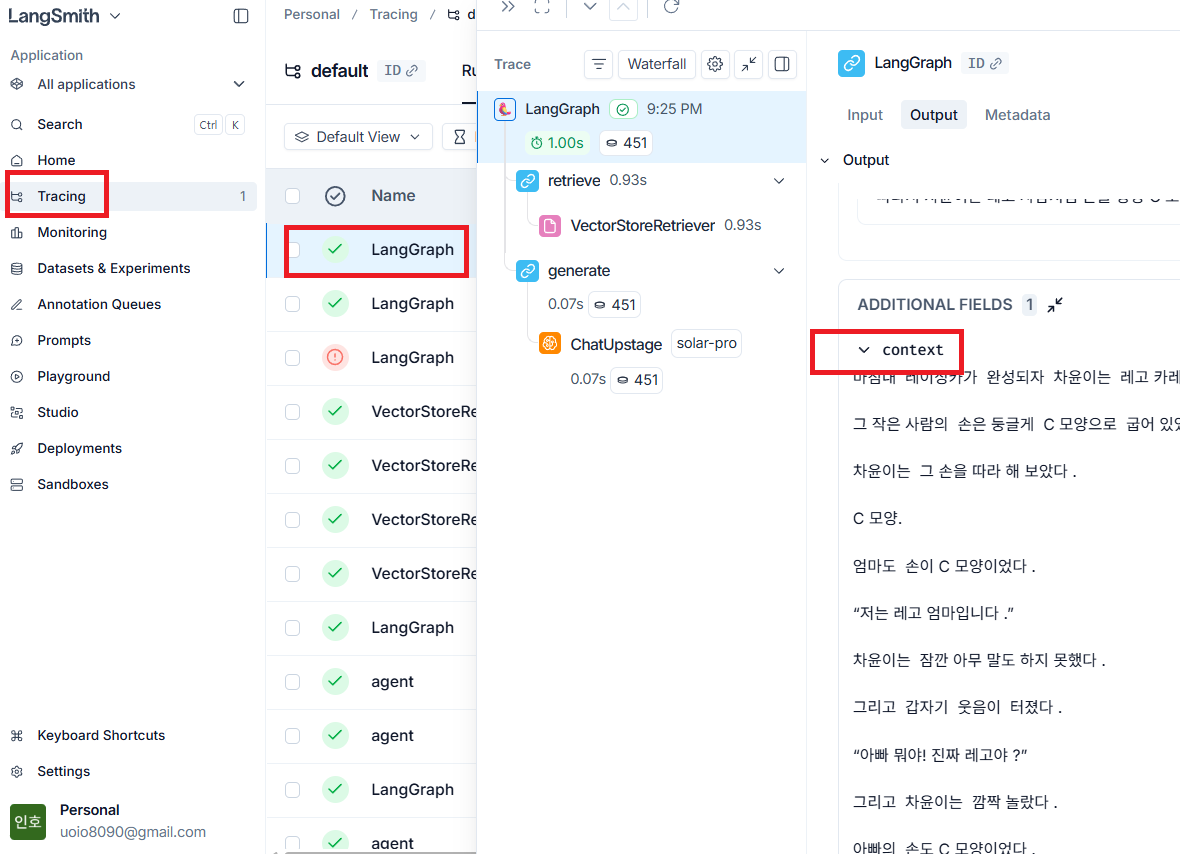

# 6. 끝으로

  - AI Workflow 개념에 대해 알아봤습니다!
  - LangGraph은 LLM에 Workflow가 필요한 경우, 유용하게 사용할 수 있는 툴입니다.
  
<br/>

**[참고사항]**
  - 아직 LangGraph 수업이 끝나지 않았습니다!!
    - 다음 수업에는 LangChain과 LaghGraph에 대한 상세한 내용을 배웁니다.
    - 다음 수업에는 Tool을 사용하는 방법도 배웁니다.

<br/>

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  